# Exploratory Data Analysis - Lobachevsky University Electrocardiography Database

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from _nb_exploratory_analysis import (
    summarize_annotation,
    summarize_database,
    summarize_database_annotations,
    summarize_record,
    summarize_signal,
    summarize_signal_quality,
)
from _nb_fiducial_analysis import (
    plot_fiducials_distributions,
    summarize_database_fiducial,
)
from wfdb.io.annotation import ann_label_table

from ecg_waveform.config import (
    LUDB_DIR,
    ensure_directories,
    get_ludb_record_names,
    load_yaml,
)
from ecg_waveform.data import WFDBLoader
from ecg_waveform.visualization import (
    plot_amplitude_distribution,
    plot_beat_overlays,
    plot_poincare,
    plot_rr_distribution,
    plot_rr_tachogram,
    plot_signal,
    set_style,
)

ensure_directories()

set_style()

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [3]:
LEADS = (
    "i", "ii", "iii", "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6",
)

loader = WFDBLoader(LUDB_DIR, {lead: lead for lead in LEADS})
record = loader[get_ludb_record_names()[0]]
signal = record.get_signal(1)

R_PEAK_SYMBOLS = load_yaml("annotation_labels.yaml")["r_peaks"]

r_peaks = signal.annotation.filter(R_PEAK_SYMBOLS)

In [4]:
summarize_record(record)

,Property,Value
0,Record name,data/1
1,Number of leads,12
2,Leads,"i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5, v6"
3,Sample rate (Hz),500
4,Number of samples,5000
5,Duration (s),10.0


In [5]:
summarize_signal(signal)

,Property,Value
0,Lead name,ii
1,Sample rate (Hz),500
2,Number of samples,5000
3,Duration (s),10.0
4,Min (mV),-0.136
5,Max (mV),0.864
6,Mean (mV),0.0
7,Std (mV),0.096
8,Dynamic range,1.0
9,Outlier ratio (%),0.0


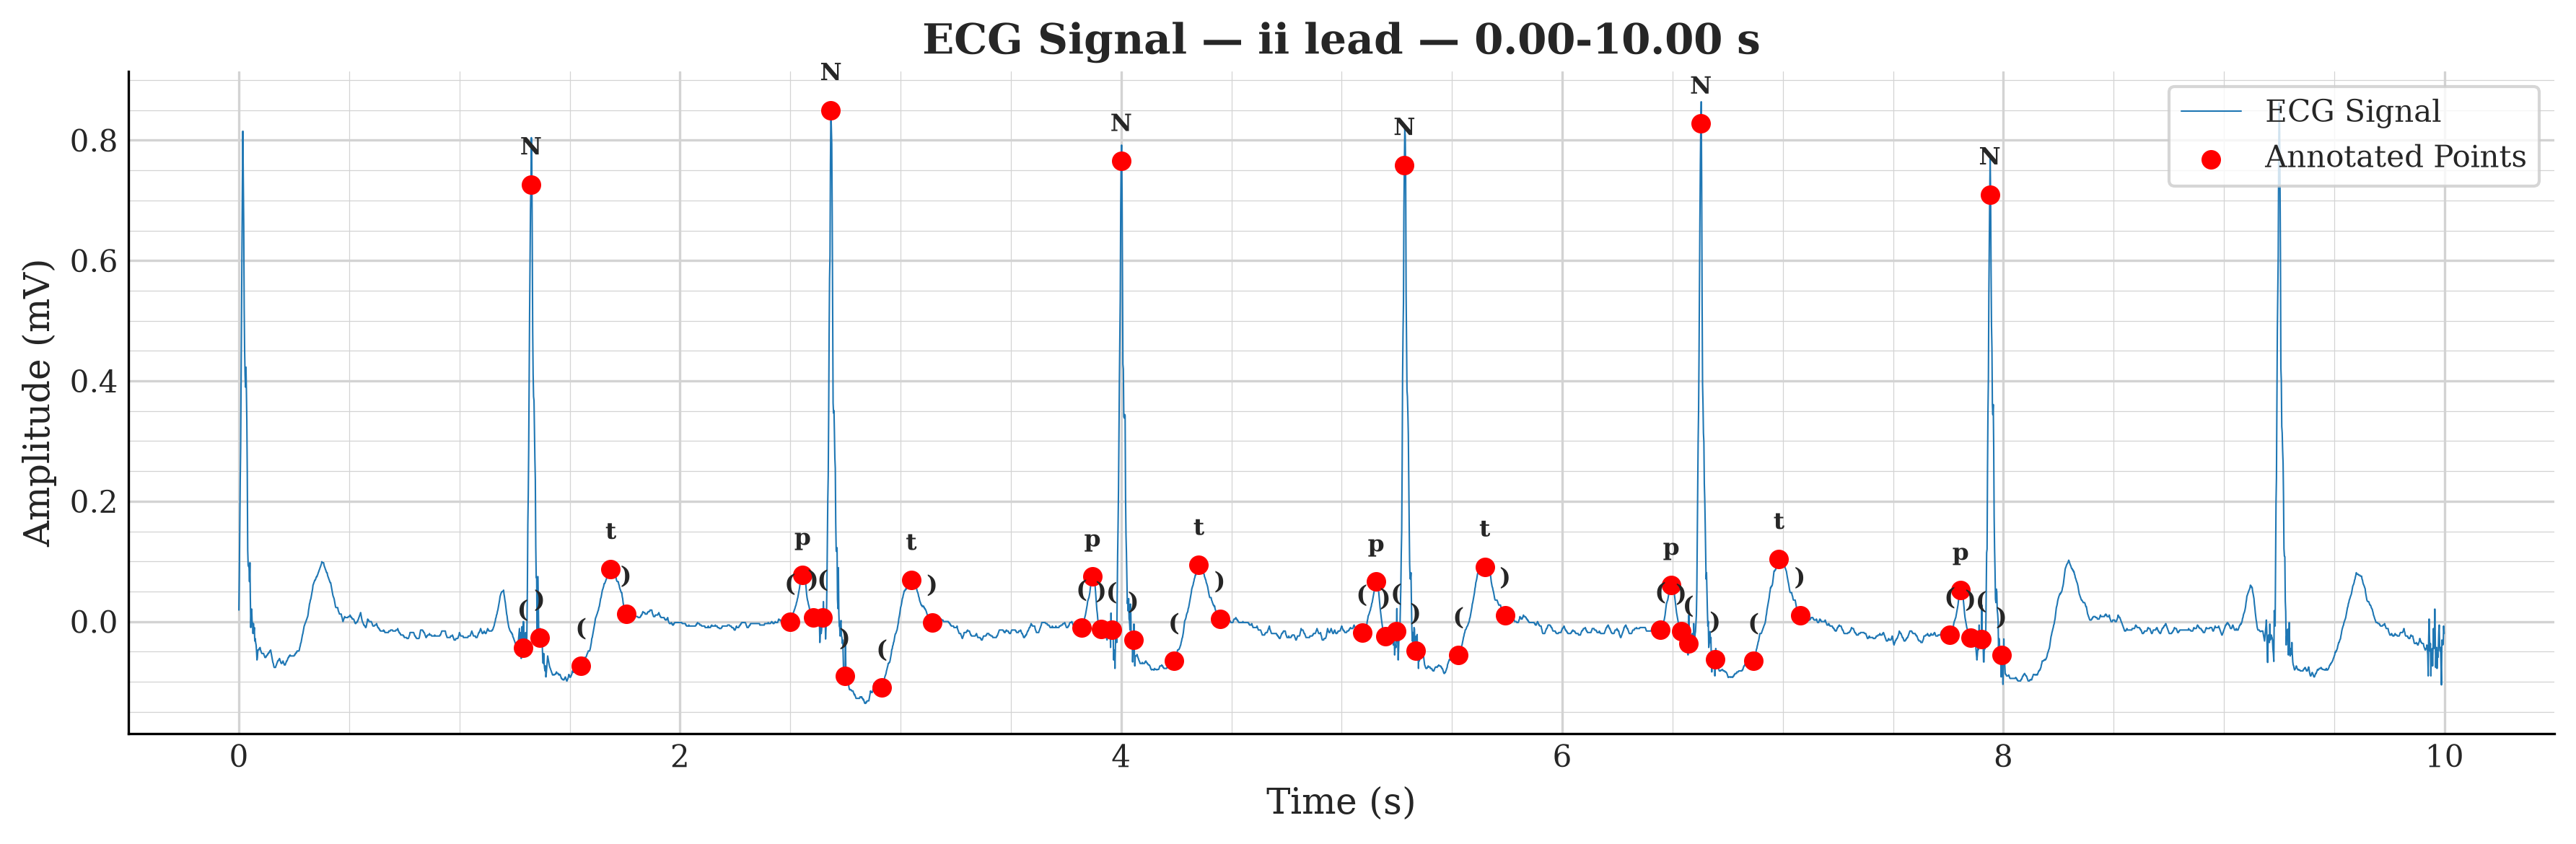

In [ ]:
fig, ax = plot_signal(signal)

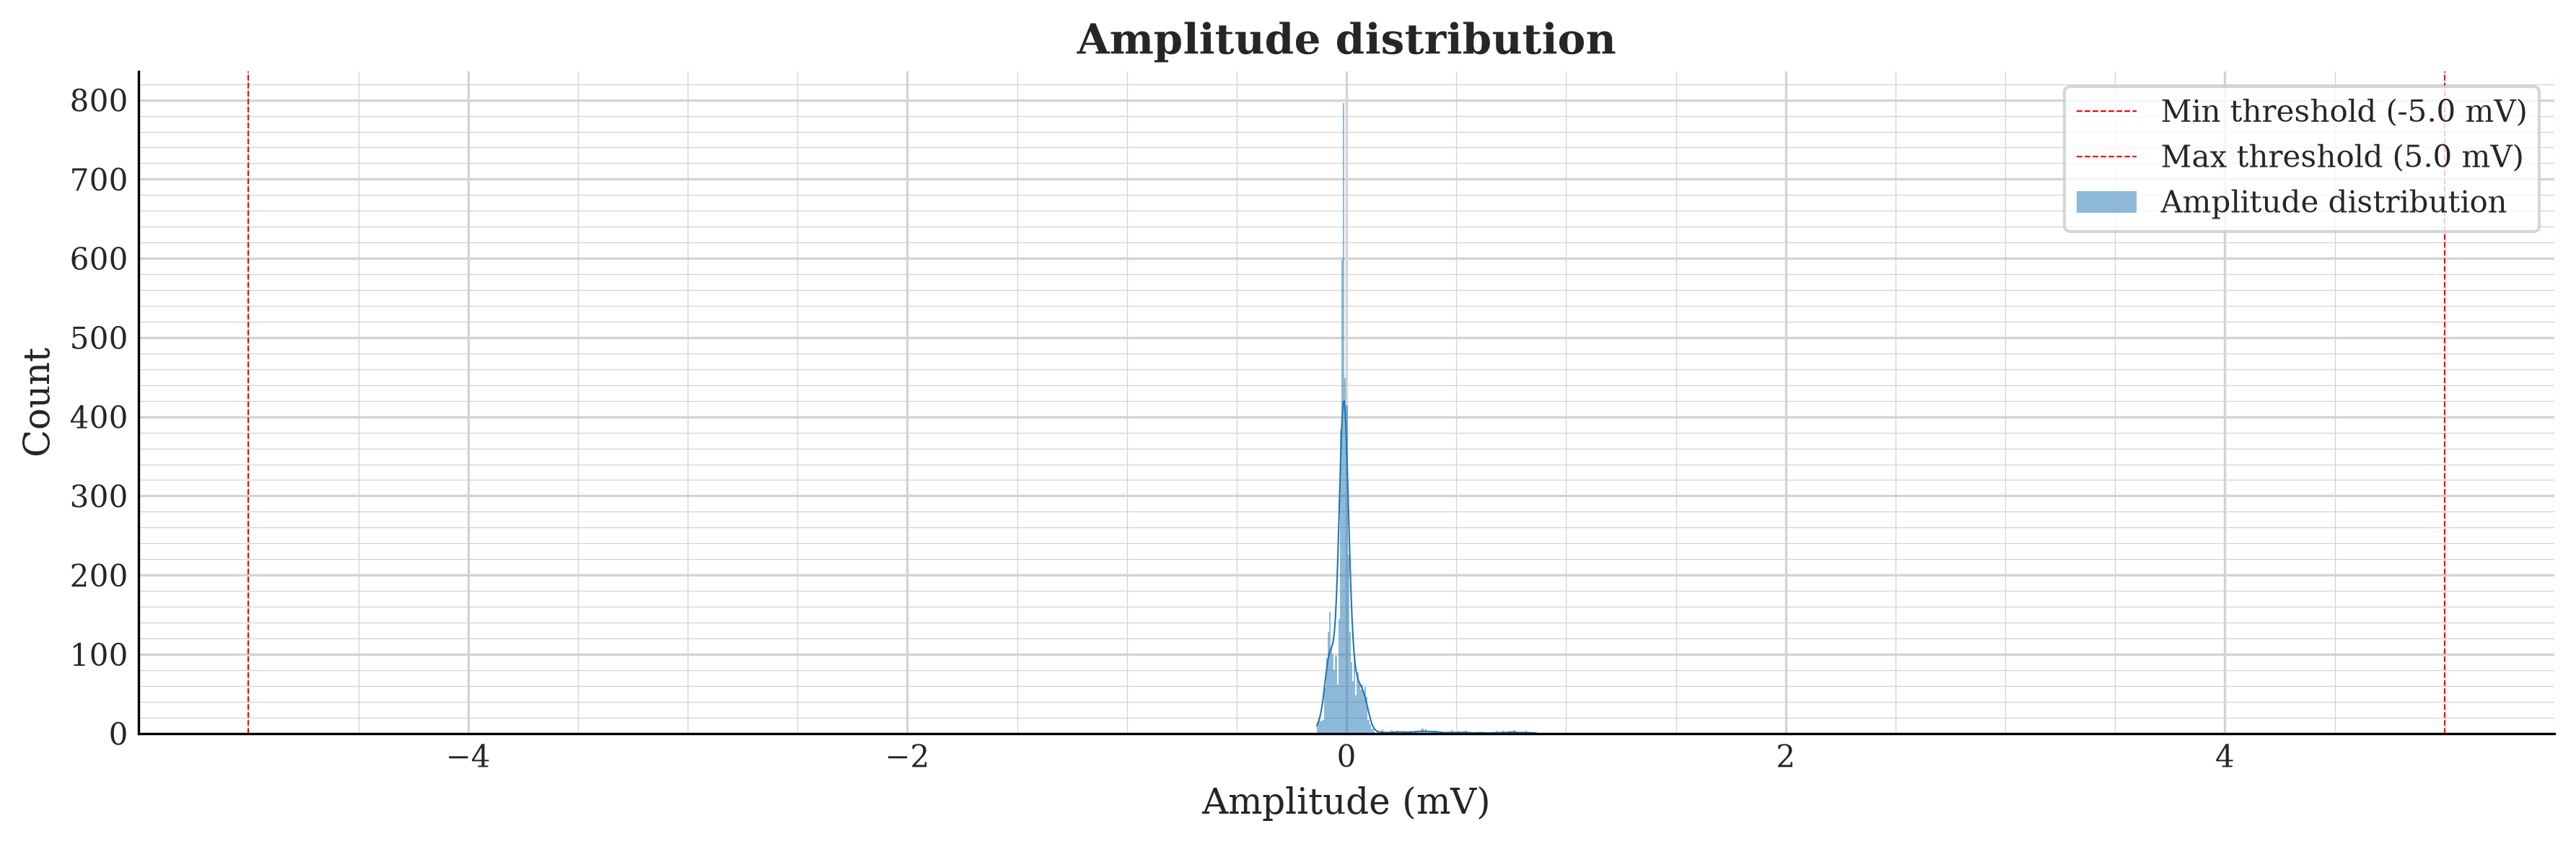

In [ ]:
fig, ax = plot_amplitude_distribution(signal)

In [8]:
summarize_signal_quality(signal)

,Property,Value
0,Kurtosis SQI,33.447
1,QRS Power SQI,0.462
2,Powerline Noise Ratio (50.0 Hz),0.001
3,Powerline Noise Ratio (60.0 Hz),0.000
4,Baseline Wander Ratio,0.027
5,Flatline Ratio,0.000


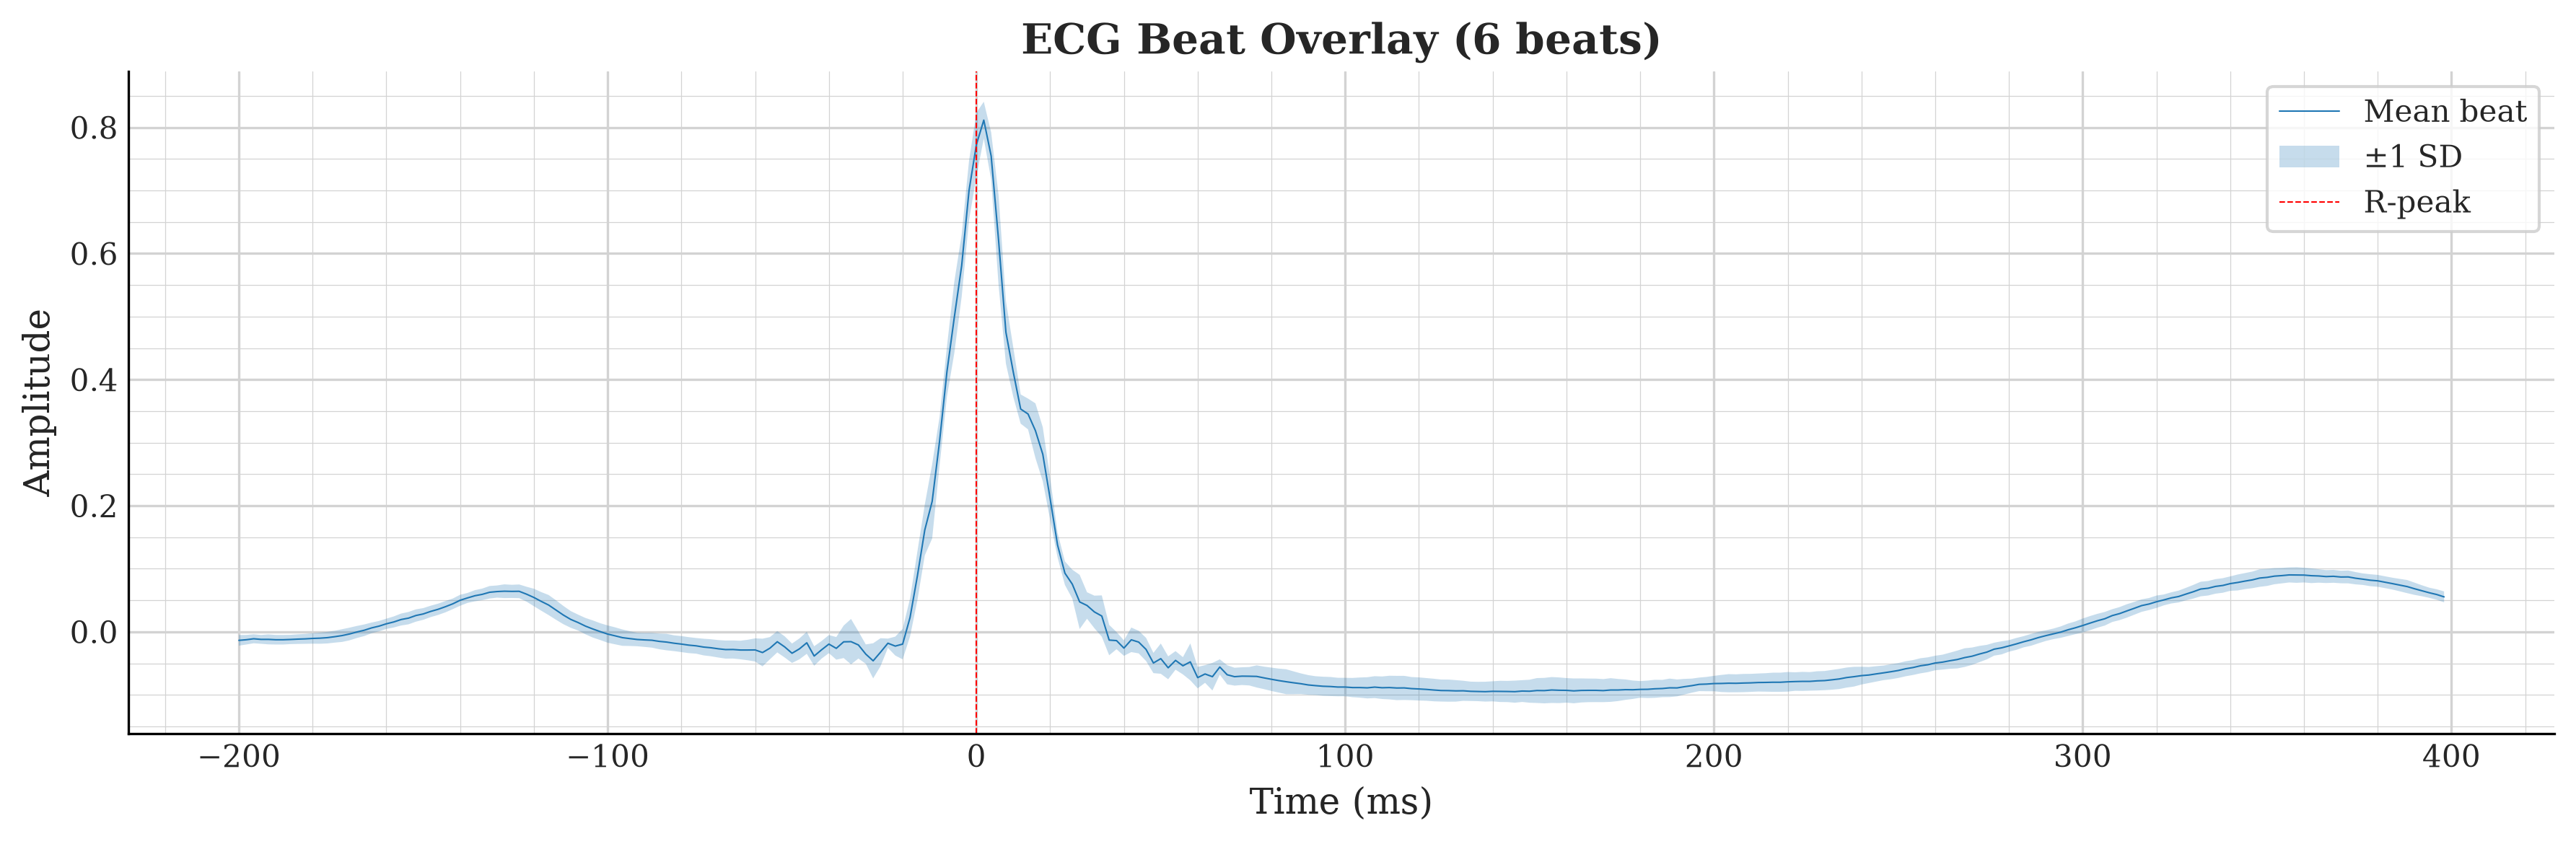

In [ ]:
fig, ax = plot_beat_overlays(signal, r_peaks)

In [10]:
pd.DataFrame(ann_label_table)[["symbol", "description"]]

,symbol,description
0,,Not an actual annotation
1,N,Normal beat
2,L,Left bundle branch block beat
3,R,Right bundle branch block beat
4,a,Aberrated atrial premature beat
5,V,Premature ventricular contraction
6,F,Fusion of ventricular and normal beat
7,J,Nodal (junctional) premature beat
8,A,Atrial premature contraction
9,S,Premature or ectopic supraventricular beat


In [11]:
summarize_annotation(signal.annotation, signal.sample_rate)

,Property,Value
0,Number of annotations,48
1,Number of unique symbols,5
2,Unique annotation symbols,"(, ), N, p, t"
3,First annotation sample,644
4,Last annotation sample,3996
5,First annotation (s),1.288
6,Last annotation (s),7.992


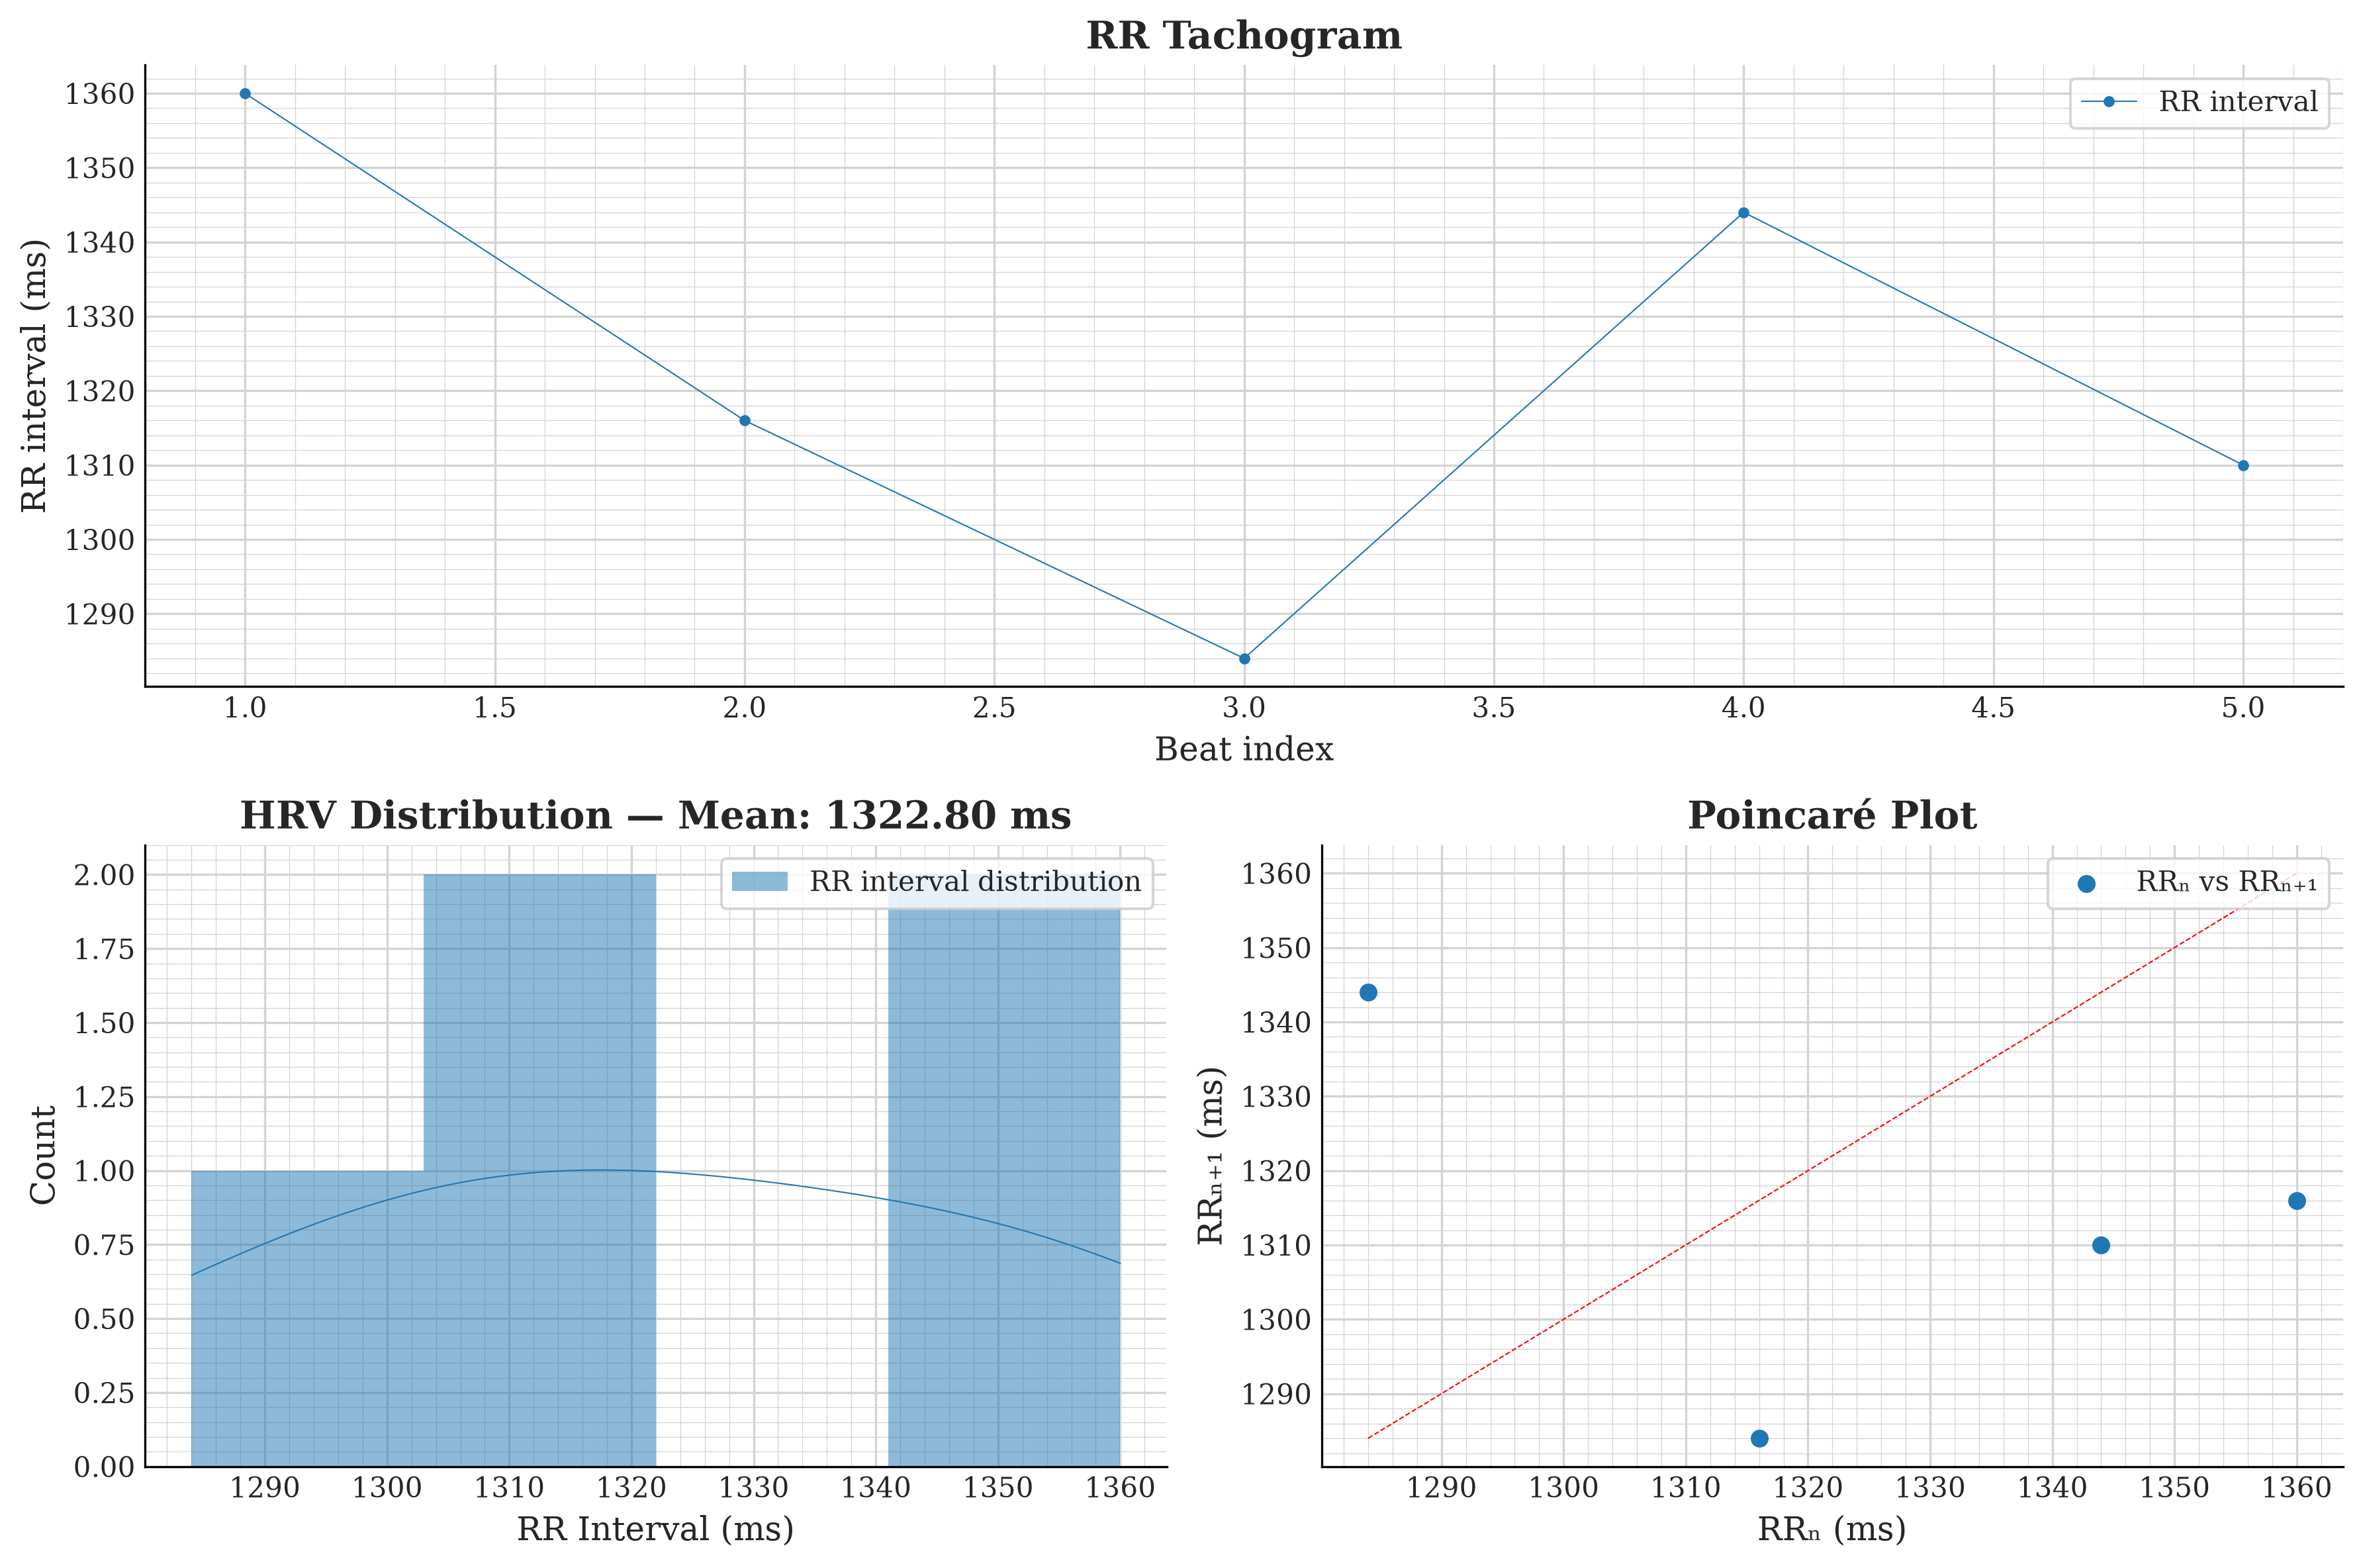

In [12]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
)

ax_top = fig.add_subplot(gs[0, :])

ax_left = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

plot_rr_tachogram(signal, r_peaks, ax=ax_top)
plot_rr_distribution(signal, r_peaks, ax=ax_left)
plot_poincare(signal, r_peaks, ax=ax_right)

fig.tight_layout()
plt.show()

In [13]:
summarize_database(LUDB_DIR, get_ludb_record_names())

,Property,Value
0,Number of records,200
1,Total lead-channels,2400
2,Unique lead names,"avf, avl, avr, i, ii, iii, v1, v2, v3, v4, v5, v6"
3,Sample rates (Hz),500
4,Total samples,1000000
5,Total duration (s),2000.0
6,Mean duration (s),10.0
7,Median duration (s),10.0
8,Mean NaN ratio (%),0.0
9,Mean outlier ratio (%),0.0


In [14]:
summarize_database_annotations(LUDB_DIR, get_ludb_record_names(), {lead: lead for lead in LEADS})

,Property,Value
0,Annotation extension,"avf-avf, avl-avl, avr-avr, i-i, ii-ii, iii-iii, v1-v1, v2-v2, v3-v3, v4-v4, v5-v5, v6-v6"
1,Records,200
2,Annotated signals,2400
3,Total annotations,175167
4,Mean annotations per signal,72.986
5,Median annotations per signal,66.0
6,Minimum annotations per signal,30
7,Maximum annotations per signal,132
8,Unique symbols,5
9,Symbols,"(, ), N, p, t"


In [15]:
fiducials_df = summarize_database_fiducial(LUDB_DIR, get_ludb_record_names(), "ii")

Successfully matched beats: 1817


,Mean (ms),Std (ms),Min (ms),Max (ms),Normal range
RR interval,881.114,176.800,360.000,1994.000,"[600, 1000]"
PP interval,897.954,165.303,568.000,2754.000,"[600, 1000]"
PR interval,162.664,28.808,82.000,366.000,"[120, 220]"
QT interval,392.145,45.102,210.000,592.000,"[350, 440]"
ST segment,114.476,39.403,20.000,286.000,"[80, 120]"
P duration,110.347,19.846,40.000,256.000,"[60, 120]"
QRS duration,97.105,20.925,54.000,250.000,"[60, 100]"
T duration,180.567,33.309,68.000,318.000,"[100, 250]"
QTc Bazett,422.603,43.871,247.301,680.497,"[350, 450]"
QTc Fridericia,411.439,39.017,240.692,634.644,"[350, 450]"


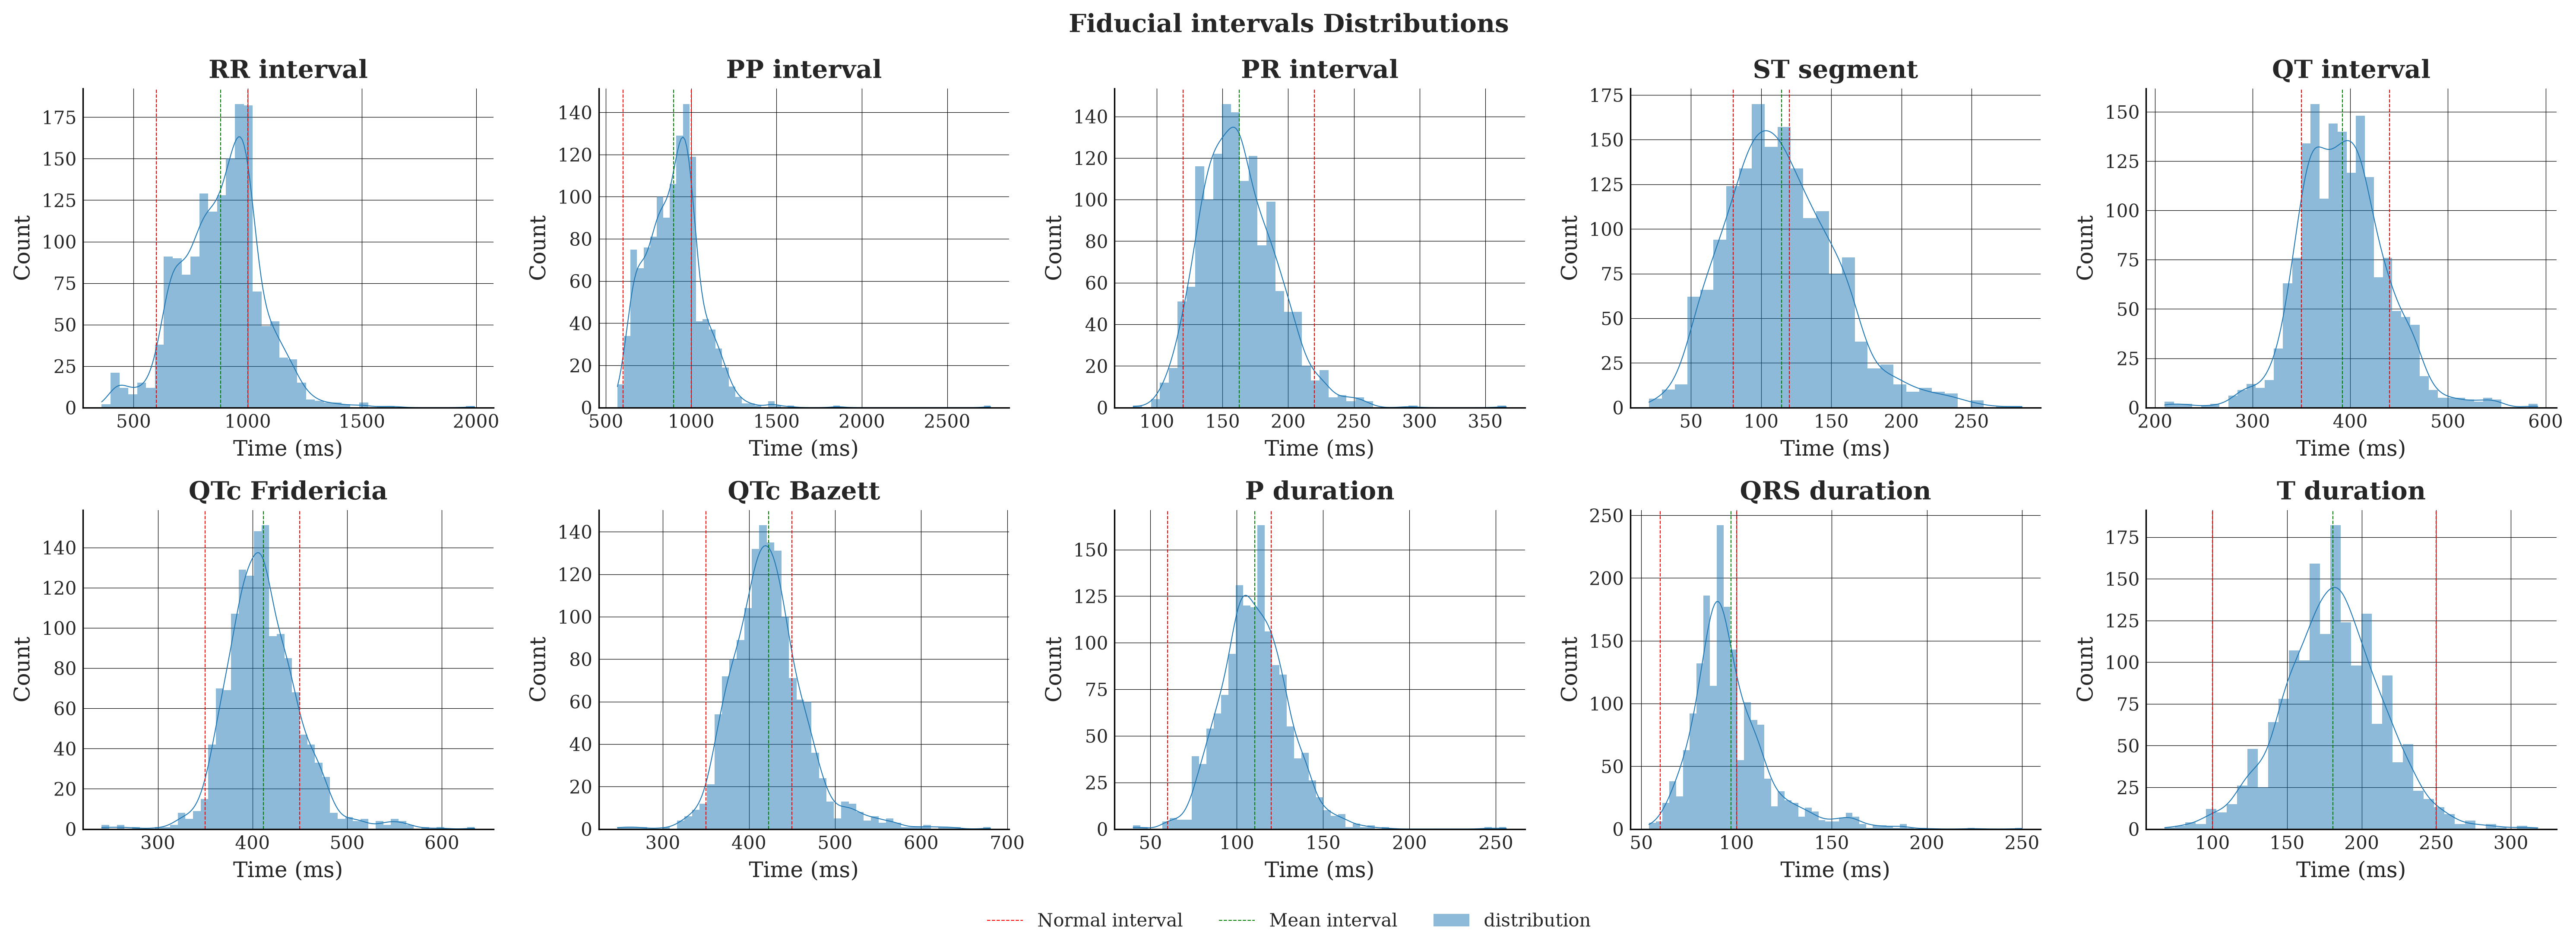

In [ ]:
fig, ax = plot_fiducials_distributions(fiducials_df)